## Tools Importations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent style for all charts
plt.rcParams['figure.figsize'] = (6, 4)
burgundy = '#800020'

## File Importation.

In [2]:
df = pd.read_csv("C:/Users/USER/Downloads/HR-Employee-Attrition-cleaned.csv")
df.head()

,Age,Age_Group,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,Education_Label,EducationField,...,RelationshipSatisfaction_Label,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,WorkLifeBalance_Label,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,36-45,Yes,Travel_Rarely,"$1,102",Sales,1,2,College,Life Sciences,...,Low,0,8,0,1,Low,6,4,0,5
1,49,46-55,No,Travel_Frequently,$279,Research & Development,8,1,Below College,Life Sciences,...,Very High,1,10,3,3,High,10,7,1,7
2,37,36-45,Yes,Travel_Rarely,"$1,373",Research & Development,2,2,College,Other,...,Medium,0,7,3,3,High,0,0,0,0
3,33,26-35,No,Travel_Frequently,"$1,392",Research & Development,3,4,Master,Life Sciences,...,High,0,8,3,3,High,8,7,3,0
4,27,26-35,No,Travel_Rarely,$591,Research & Development,2,1,Below College,Medical,...,Very High,1,6,3,3,High,2,2,2,2


## Checking data types, row/column counts, and missing values before analysis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             1470 non-null   int64
 1   Age_Group                       1470 non-null   str  
 2   Attrition                       1470 non-null   str  
 3   BusinessTravel                  1470 non-null   str  
 4   DailyRate                       1470 non-null   str  
 5   Department                      1470 non-null   str  
 6   DistanceFromHome                1470 non-null   int64
 7   Education                       1470 non-null   int64
 8   Education_Label                 1470 non-null   str  
 9   EducationField                  1470 non-null   str  
 10  EmployeeNumber                  1470 non-null   int64
 11  EnvironmentSatisfaction         1470 non-null   int64
 12  EnvironmentSatisfaction_Label   1470 non-null   str  
 13  Gender        

## Missing values check

In [4]:
df.isnull().sum()

Age                               0
Age_Group                         0
Attrition                         0
BusinessTravel                    0
DailyRate                         0
Department                        0
DistanceFromHome                  0
Education                         0
Education_Label                   0
EducationField                    0
EmployeeNumber                    0
EnvironmentSatisfaction           0
EnvironmentSatisfaction_Label     0
Gender                            0
HourlyRate                        0
JobInvolvement                    0
JobInvolvement_Label              0
JobLevel                          0
JobLevel_Label                    0
JobRole                           0
JobSatisfaction                   0
JobSatisfaction_Label             0
MaritalStatus                     0
MonthlyIncome                     0
MonthlyRate                       0
NumCompaniesWorked                0
OverTime                          0
PercentSalaryHike           

## Attrition Rate by Department

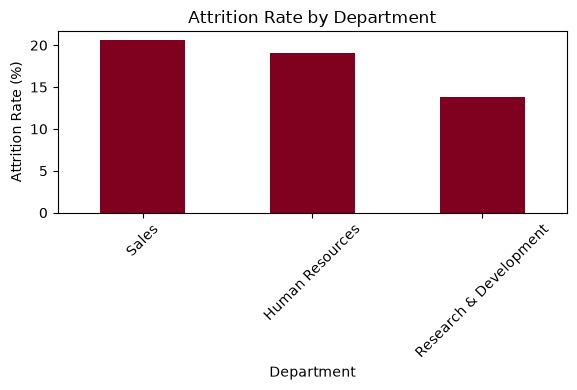

In [5]:
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
dept_attrition = dept_attrition.sort_values(ascending=False)
dept_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by OverTime

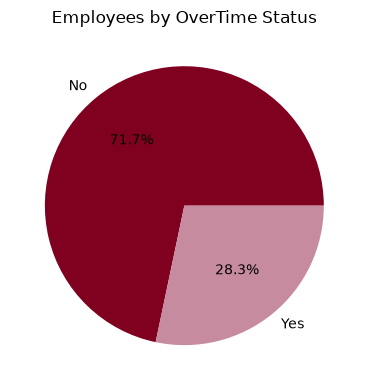

In [6]:
overtime_counts = df['OverTime'].value_counts()
overtime_counts.plot(kind='pie', autopct='%1.1f%%', colors=[burgundy, '#c78ba0'], figsize=(6,4))
plt.title('Employees by OverTime Status')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Attrition Rate by Job Satisfaction

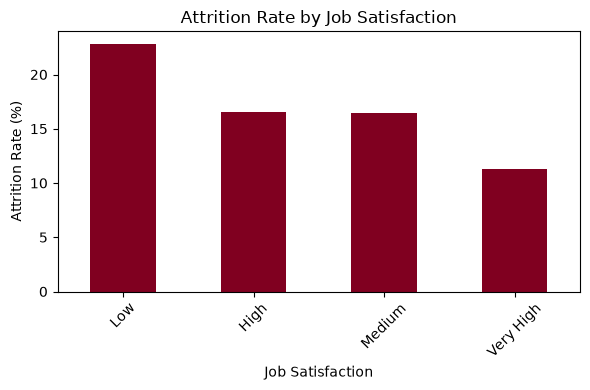

In [11]:
jobsat_attrition = df.groupby('JobSatisfaction_Label')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
jobsat_attrition = jobsat_attrition.sort_values(ascending=False)
jobsat_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Job Satisfaction')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Satisfaction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Age Group

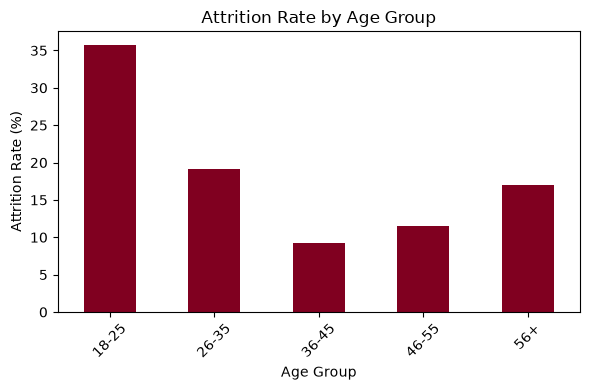

In [12]:
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
age_attrition = df.groupby('Age_Group')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
age_attrition = age_attrition.reindex(age_order)
age_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Job Role

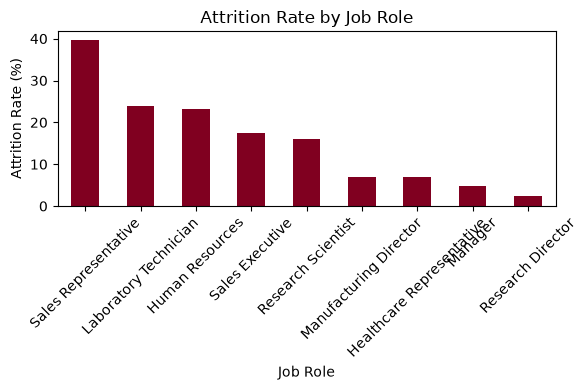

In [13]:
jobrole_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
jobrole_attrition = jobrole_attrition.sort_values(ascending=False)
jobrole_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Marital Status

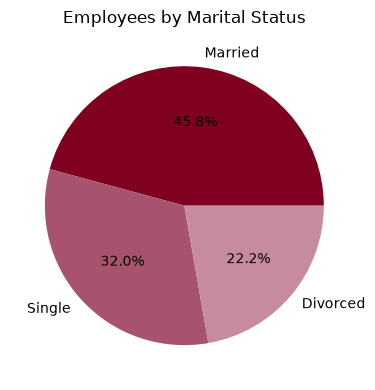

In [14]:
marital_counts = df['MaritalStatus'].value_counts()
marital_colors = [burgundy, '#a8536e', '#c78ba0']
marital_counts.plot(kind='pie', autopct='%1.1f%%', colors=marital_colors, figsize=(6,4))
plt.title('Employees by Marital Status')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Average Monthly Income by Job Role

In [18]:
df['MonthlyIncome'] = df['MonthlyIncome'].replace(r'[$,]', '', regex=True).astype(float)

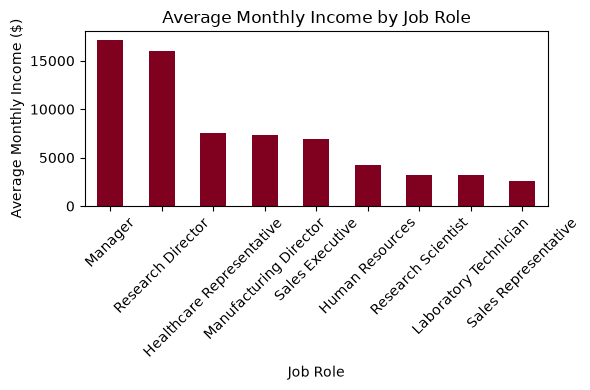

In [19]:
avg_income = df.groupby('JobRole')['MonthlyIncome'].mean()
avg_income = avg_income.sort_values(ascending=False)
avg_income.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Average Monthly Income by Job Role')
plt.ylabel('Average Monthly Income ($)')
plt.xlabel('Job Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Years At Company

In [22]:
df['YearsAtCompany_Group'] = pd.cut(df['YearsAtCompany'], bins=[-1,2,5,10,float('inf')], labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs'])

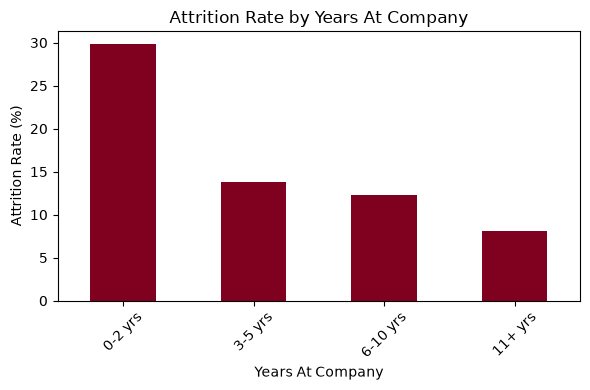

In [25]:
years_order = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs']
years_attrition = df.groupby('YearsAtCompany_Group')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
years_attrition = years_attrition.reindex(years_order)
years_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Years At Company')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Years At Company')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Distance From Home

In [32]:
df['DistanceFromHome_Group'] = pd.cut(df['DistanceFromHome'], bins=[-1, 5, 10, 20, float('inf')], labels=['0-5 km', '6-10 km', '11-20 km', '21+ km'])

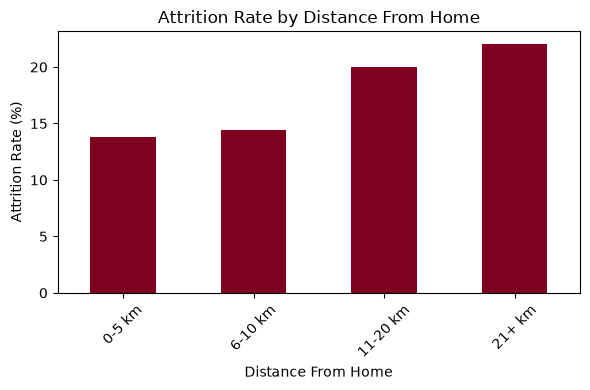

In [33]:
distance_order = ['0-5 km', '6-10 km', '11-20 km', '21+ km']
distance_attrition = df.groupby('DistanceFromHome_Group')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
distance_attrition = distance_attrition.reindex(distance_order)
distance_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Distance From Home')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Distance From Home')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Attrition Rate by Business Travel

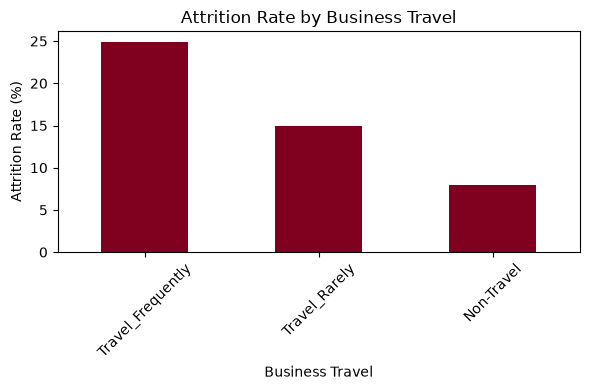

In [34]:
travel_attrition = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
travel_attrition = travel_attrition.sort_values(ascending=False)
travel_attrition.plot(kind='bar', color=burgundy, figsize=(6,4))
plt.title('Attrition Rate by Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Business Travel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()